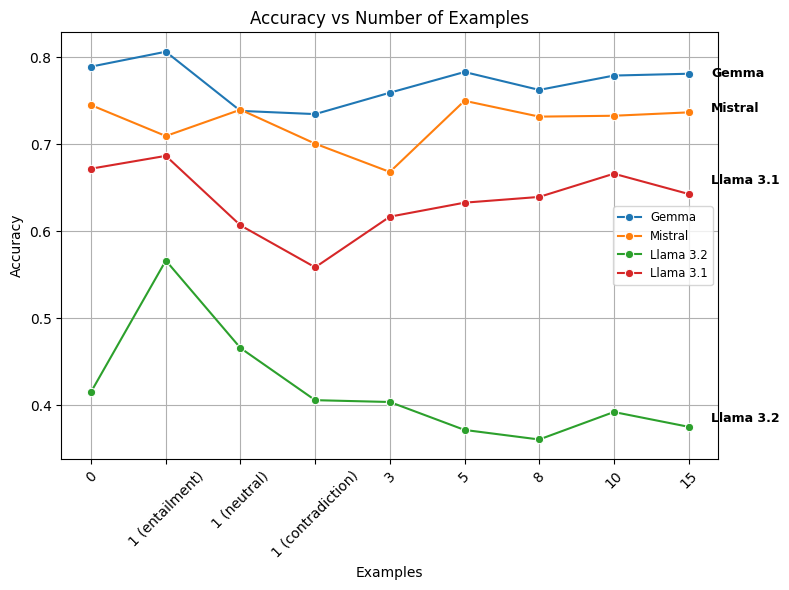

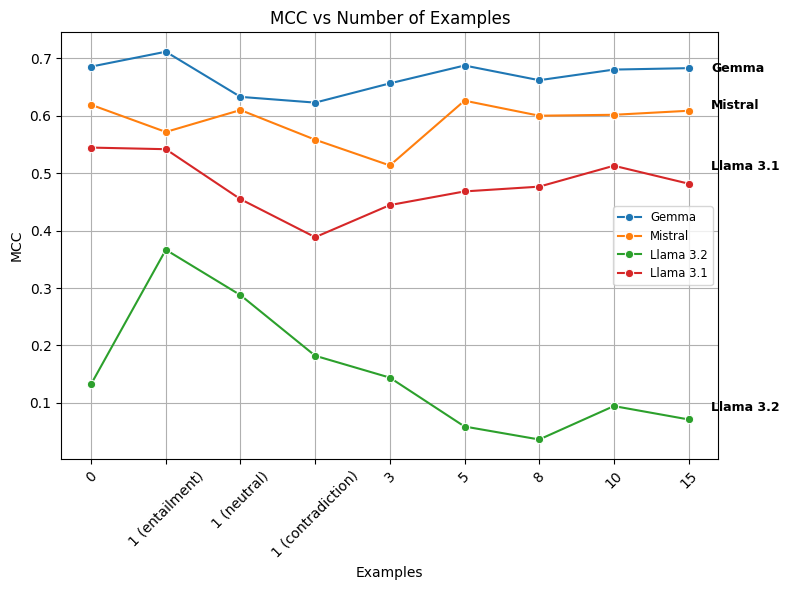

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('NLI & LLMs Results - MNLI_m.csv')

# Function to shorten labels
def shorten_label(s):
    if s == '1 - Entailment':
        return '1 (entailment)'
    elif s == '1 - Neutral':
        return '1 (neutral)'
    elif s == '1 - Contradiction':
        return '1 (contradiction)'
    else:
        return s.split()[0]

# Add short_examples column
df['short_examples'] = df['Examples'].apply(shorten_label)

# Define the order for short_examples
short_order = ['0', '1 (entailment)', '1 (neutral)', '1 (contradiction)', '3', '5', '8', '10', '15']

# Set short_examples as categorical with order
df['short_examples'] = pd.Categorical(df['short_examples'], categories=short_order, ordered=True)

# Sort by short_examples
df = df.sort_values('short_examples')

# Plot Accuracy in its own figure
plt.figure(figsize=(8, 6))
for model in df['Model'].unique():
    subset = df[df['Model'] == model]
    sns.lineplot(data=subset, x='short_examples', y='Accuracy', marker='o', label=model)
plt.title('Accuracy vs Number of Examples')
plt.xlabel('Examples')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
for i, line in enumerate(plt.gca().lines):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    if len(xdata) > 0:
        plt.text(xdata[-1] + 0.3, ydata[-1] + 0.005 * i, line.get_label(), ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot MCC in its own figure
plt.figure(figsize=(8, 6))
for model in df['Model'].unique():
    subset = df[df['Model'] == model]
    sns.lineplot(data=subset, x='short_examples', y='MCC', marker='o', label=model)
plt.title('MCC vs Number of Examples')
plt.xlabel('Examples')
plt.ylabel('MCC')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
for i, line in enumerate(plt.gca().lines):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    if len(xdata) > 0:
        plt.text(xdata[-1] + 0.3, ydata[-1] + 0.01 * i, line.get_label(), ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()